In [2]:
# STEP 1: Libraries for K-Means

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans


In [4]:
df = pd.read_csv("cluster_data.csv")
df.head()


,Feature 1,Feature 2
0,2.698582,-0.672960
1,-0.128113,4.355952
2,2.509049,5.773146
3,-1.518276,3.444886
4,-0.072283,2.883769


In [6]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Feature 1  500 non-null    float64
 1   Feature 2  500 non-null    float64
dtypes: float64(2)
memory usage: 7.9 KB


In [8]:
df.describe()


,Feature 1,Feature 2
count,500.000000,500.000000
mean,1.831353,2.694970
std,4.086149,3.494165
min,-3.896491,-4.378493
25%,-1.174033,0.200712
50%,0.604212,2.807746
75%,2.750212,5.132506
max,11.867680,10.216205


In [10]:
df.shape


(500, 2)

In [12]:
df.isnull().sum()


Feature 1    0
Feature 2    0
dtype: int64

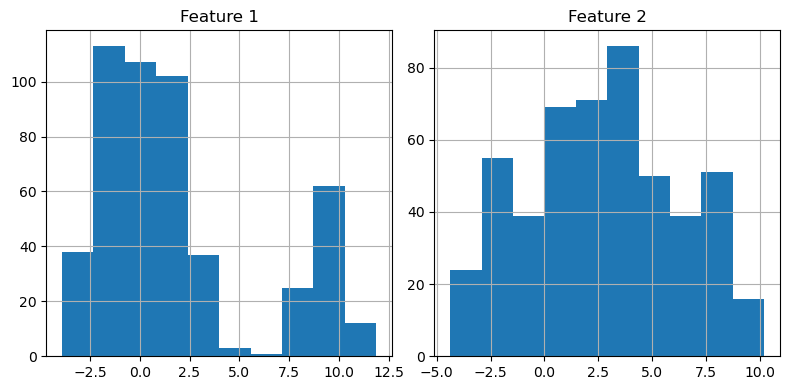

In [14]:
df.hist(figsize=(8, 4))
plt.tight_layout()
plt.show()


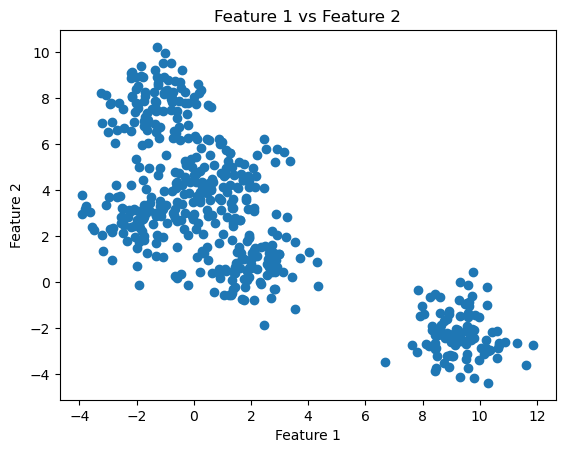

In [16]:
plt.scatter(df["Feature 1"], df["Feature 2"])
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Feature 1 vs Feature 2")
plt.show()


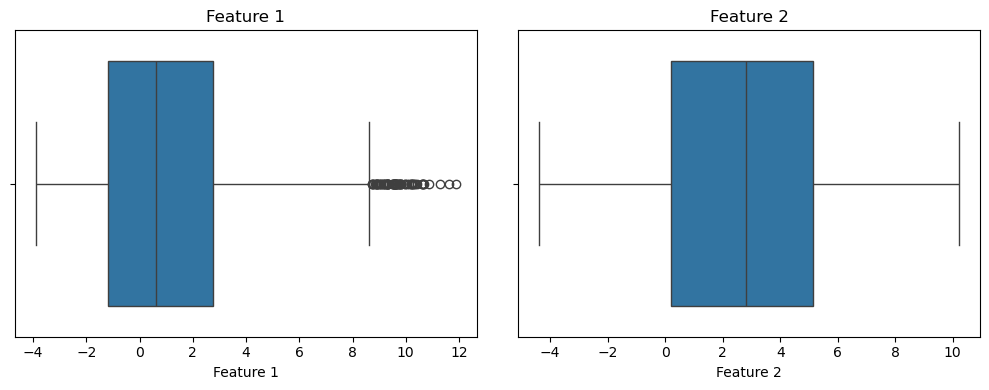

In [18]:
plt.figure(figsize=(10, 4))

for i, col in enumerate(df.columns, 1):
    plt.subplot(1, 2, i)
    sns.boxplot(x=df[col])
    plt.title(col)

plt.tight_layout()
plt.show()


In [20]:
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower_limit) | (df[col] > upper_limit)]

    print(f"{col}: {len(outliers)} outliers")


Feature 1: 74 outliers
Feature 2: 0 outliers


In [22]:
scaler = StandardScaler()

df_scaled = scaler.fit_transform(df)

df_scaled = pd.DataFrame(df_scaled, columns=df.columns)

df_scaled.head()


,Feature 1,Feature 2
0,0.212449,-0.964838
1,-0.480019,0.475835
2,0.166018,0.881830
3,-0.820573,0.214835
4,-0.466342,0.054087


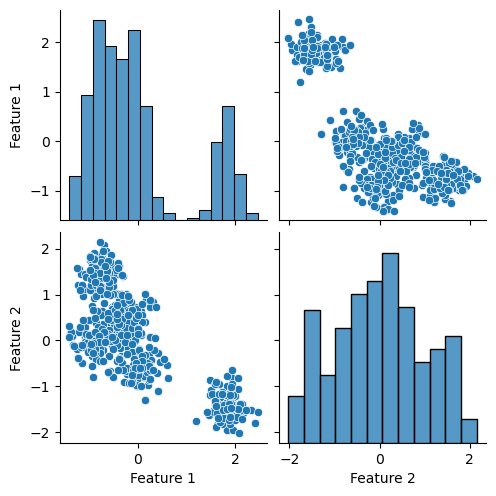

In [24]:
sns.pairplot(df_scaled)
plt.show()


In [26]:
corr_matrix = df_scaled.corr()
corr_matrix


,Feature 1,Feature 2
Feature 1,1.000000,-0.767391
Feature 2,-0.767391,1.000000


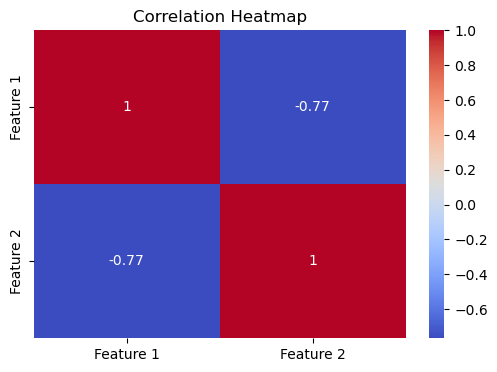

In [28]:
plt.figure(figsize=(6, 4))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()


In [36]:
import os
os.environ["OMP_NUM_THREADS"] = "1"

C:\Users\ASUS\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\ASUS\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\ASUS\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\ASUS\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows wi

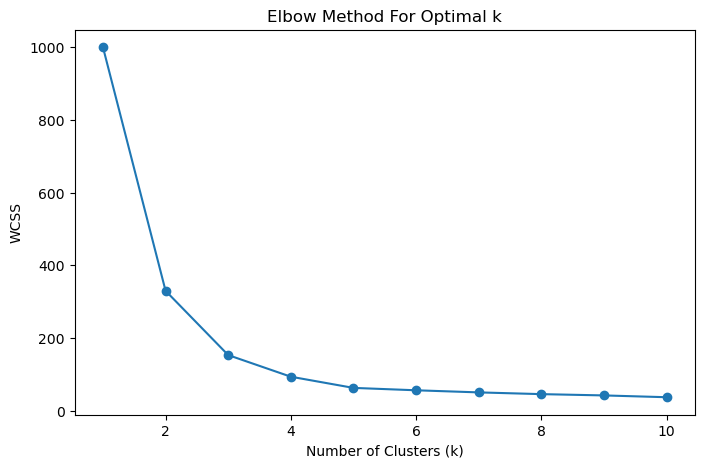

In [44]:



wcss = []
K_values = range(1, 11)

for k in K_values:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(df_scaled)
    wcss.append(kmeans.inertia_)

# Plot WCSS vs K
plt.figure(figsize=(8,5))
plt.plot(K_values, wcss, marker='o')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("WCSS")
plt.title("Elbow Method For Optimal k")
plt.show()

In [46]:
kmeans.fit(df_scaled)


C:\Users\ASUS\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


KMeans(n_clusters=10, random_state=42)

In [48]:
clusters = kmeans.predict(df_scaled)


In [50]:
df_scaled["Cluster"] = clusters
df_scaled.head()

,Feature 1,Feature 2,Cluster
0,0.212449,-0.964838,7
1,-0.480019,0.475835,8
2,0.166018,0.881830,0
3,-0.820573,0.214835,8
4,-0.466342,0.054087,8


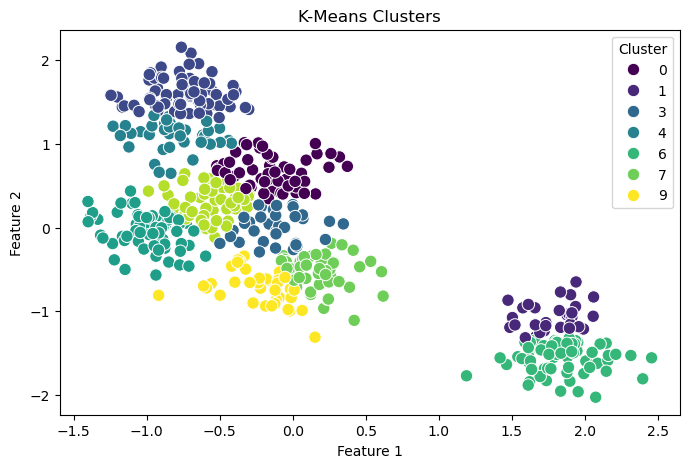

In [52]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x=df_scaled["Feature 1"],
    y=df_scaled["Feature 2"],
    hue=df_scaled["Cluster"],
    palette="viridis",
    s=80
)

plt.title("K-Means Clusters")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()


In [54]:
centers = kmeans.cluster_centers_
centers


array([[-0.14879593,  0.66850938],
       [ 1.77953801, -1.06163629],
       [-0.75003491,  1.60267054],
       [-0.11550482,  0.01031424],
       [-0.81553205,  1.09140287],
       [-0.99469017, -0.04792871],
       [ 1.85209757, -1.56386315],
       [ 0.18424997, -0.53363511],
       [-0.55889734,  0.29582922],
       [-0.21963458, -0.7168026 ]])

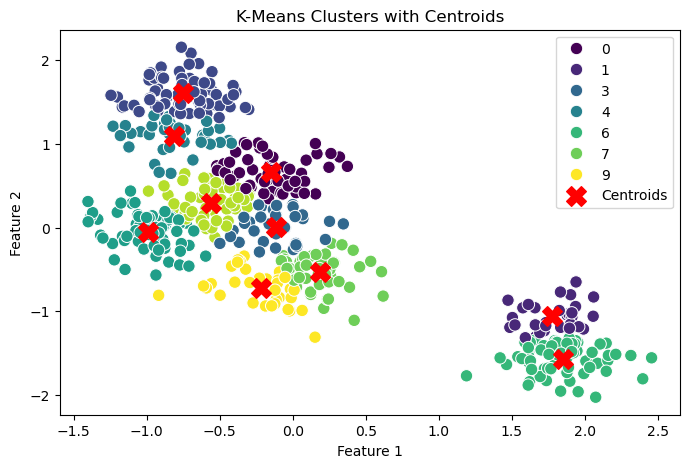

In [56]:
plt.figure(figsize=(8,5))

# Plot clusters
sns.scatterplot(
    x=df_scaled["Feature 1"],
    y=df_scaled["Feature 2"],
    hue=df_scaled["Cluster"],
    palette="viridis",
    s=80,
    legend=True
)

# Plot centroids
plt.scatter(
    centers[:,0],
    centers[:,1],
    c='red',
    s=200,
    marker='X',
    label='Centroids'
)

plt.title("K-Means Clusters with Centroids")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.show()
